In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
df= pd.read_csv("/content/dataset.csv")
df.head()

,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Tgl Lahir,...,range dp,wilayah,9 segment,kode motor,OTR,tahun rakit,DLR group,tgl cetak,tgl mohon,Kode Kota-Provinsi
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1992-03-03 0:00:00,...,2 - 3 juta,6471.0,AT LOW,HN,18685000.0,NaN,NaN,NaN,02-01-2019,6471-6400
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1991-04-27 0:00:00,...,3 jt up,6471.0,AT LOW,HN,18685000.0,NaN,NaN,NaN,02012019,6471-6400
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1982-01-04 0:00:00,...,kurang 1 juta,6471.0,AT MID,HR,20775000.0,NaN,NaN,NaN,02012019,6471-6400
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1997-06-26 0:00:00,...,krg 1 jt,6471.0,AT MID,HR,20775000.0,NaN,NaN,NaN,02012019,6471-6400
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1996-07-12 0:00:00,...,2 - 3 jt,6471.0,AT MID,HR,20775000.0,NaN,NaN,NaN,02-01-2019,6471-6400


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319978 entries, 0 to 319977
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer ID         319964 non-null  object 
 1   Kelurahan           319962 non-null  object 
 2   Kecamatan           319963 non-null  object 
 3   Kode POS            319963 non-null  object 
 4   Cash/Credit         319963 non-null  float64
 5   Kode Dealer         319963 non-null  float64
 6   Finance Company     319889 non-null  object 
 7   Tenor               319942 non-null  object 
 8   Gender              319962 non-null  object 
 9   Tgl Lahir           319963 non-null  object 
 10  Agama               319963 non-null  object 
 11  Pekerjaan           319963 non-null  object 
 12  umur                319963 non-null  float64
 13  dp aktual           319234 non-null  object 
 14  cicilan             319276 non-null  object 
 15  warna               319963 non-nul

In [ ]:
df.describe()

,Cash/Credit,Kode Dealer,umur,OTR,tgl cetak
count,319963.000000,319963.000000,319963.000000,3.199590e+05,1.322600e+04
mean,1.564146,29590.377194,94.346583,6.541080e+07,1.334797e+07
std,0.495869,44345.496360,134.293311,9.053097e+07,8.308178e+06
min,1.000000,733.000000,0.000000,0.000000e+00,1.042019e+06
25%,1.000000,10412.000000,28.000000,2.117000e+07,6.032019e+06
50%,2.000000,13115.000000,39.000000,2.361500e+07,1.210202e+07
75%,2.000000,16919.000000,53.000000,3.404000e+07,1.908202e+07
max,2.000000,168507.000000,1230.000000,9.301000e+08,3.112202e+07


In [ ]:
df.isnull().sum()

,0
Customer ID,14
Kelurahan,16
Kecamatan,15
Kode POS,15
Cash/Credit,15
Kode Dealer,15
Finance Company,89
Tenor,36
Gender,16
Tgl Lahir,15


In [ ]:
df.duplicated().sum()

np.int64(2341)

In [ ]:
df_drop=df.drop_duplicates()

In [ ]:
df_drop.duplicated().sum()

np.int64(0)

In [ ]:
df_drop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317637 entries, 0 to 319977
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer ID         317636 non-null  object 
 1   Kelurahan           317634 non-null  object 
 2   Kecamatan           317635 non-null  object 
 3   Kode POS            317635 non-null  object 
 4   Cash/Credit         317635 non-null  float64
 5   Kode Dealer         317635 non-null  float64
 6   Finance Company     317562 non-null  object 
 7   Tenor               317614 non-null  object 
 8   Gender              317634 non-null  object 
 9   Tgl Lahir           317635 non-null  object 
 10  Agama               317635 non-null  object 
 11  Pekerjaan           317635 non-null  object 
 12  umur                317635 non-null  float64
 13  dp aktual           316937 non-null  object 
 14  cicilan             316979 non-null  object 
 15  warna               317635 non-null  ob

In [ ]:
df_drop=df_drop.drop(columns=["DLR group","tgl cetak","tgl mohon"])


In [ ]:
df_drop.columns.to_list()

['Customer ID',
 'Kelurahan',
 'Kecamatan',
 'Kode POS',
 'Cash/Credit',
 'Kode Dealer',
 'Finance Company',
 'Tenor',
 'Gender',
 'Tgl Lahir',
 'Agama',
 'Pekerjaan',
 'umur',
 'dp aktual',
 'cicilan',
 'warna',
 'dealer',
 'type series',
 'range dp',
 'wilayah',
 '9 segment',
 'kode motor',
 'OTR',
 'tahun rakit',
 'Kode Kota-Provinsi']

In [ ]:
num_cols=df_drop.select_dtypes(include=np.number).columns
num_cols

Index(['Cash/Credit', 'Kode Dealer', 'umur', 'OTR'], dtype='object')

In [ ]:
cat_cols=df_drop.select_dtypes(exclude=np.number).columns
cat_cols

Index(['Customer ID', 'Kelurahan', 'Kecamatan', 'Kode POS', 'Finance Company',
       'Tenor', 'Gender', 'Tgl Lahir', 'Agama', 'Pekerjaan', 'dp aktual',
       'cicilan', 'warna', 'dealer', 'type series', 'range dp', 'wilayah',
       '9 segment', 'kode motor', 'tahun rakit', 'Kode Kota-Provinsi'],
      dtype='object')

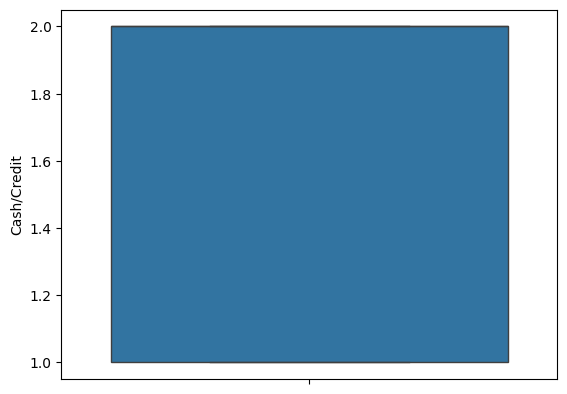

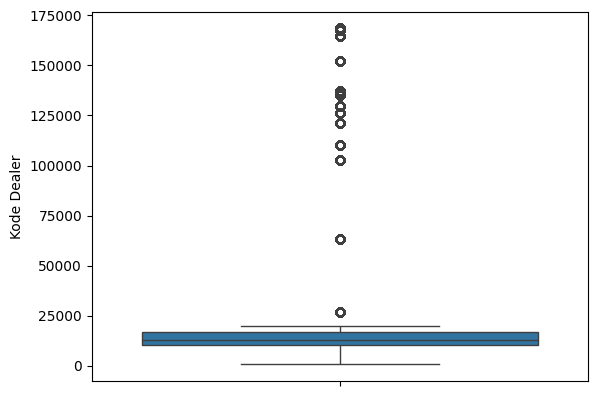

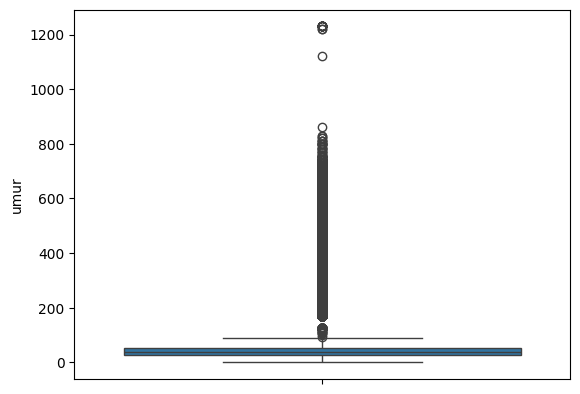

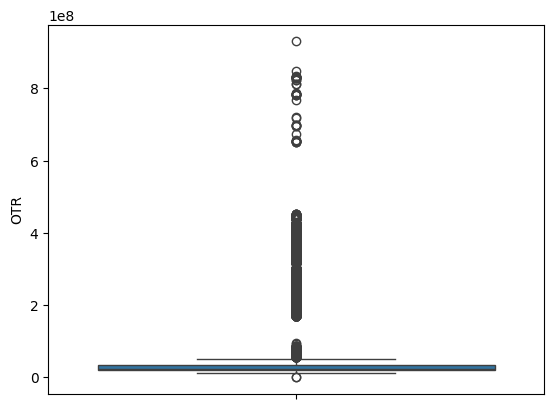

In [ ]:
for cols in num_cols:
    sns.boxplot(df_drop[cols])
    plt.show()

In [ ]:
for col in num_cols:
    Q1 = df_drop[col].quantile(0.25)
    Q3 = df_drop[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_drop[(df_drop[col] < lower_bound) | (df_drop[col] > upper_bound)]
    print(f"Column: {col}")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"  Number of outliers: {len(outliers)}\n")

Column: Cash/Credit
  Q1: 1.00, Q3: 2.00, IQR: 1.00
  Lower Bound: -0.50, Upper Bound: 3.50
  Number of outliers: 0

Column: Kode Dealer
  Q1: 10412.00, Q3: 16919.00, IQR: 6507.00
  Lower Bound: 651.50, Upper Bound: 26679.50
  Number of outliers: 51745

Column: umur
  Q1: 28.00, Q3: 53.00, IQR: 25.00
  Lower Bound: -9.50, Upper Bound: 90.50
  Number of outliers: 58060

Column: OTR
  Q1: 21160000.00, Q3: 34050000.00, IQR: 12890000.00
  Lower Bound: 1825000.00, Upper Bound: 53385000.00
  Number of outliers: 58272



### Outlier Treatment using IQR Capping

I will use the Interquartile Range (IQR) method to cap outliers in the numerical columns. This involves replacing values that fall below the `lower_bound` with the `lower_bound` itself, and values that fall above the `upper_bound` with the `upper_bound`.

In [ ]:
for col in num_cols:
    Q1 = df_drop[col].quantile(0.25)
    Q3 = df_drop[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    df_drop[col] = np.where(df_drop[col] < lower_bound, lower_bound, df_drop[col])
    df_drop[col] = np.where(df_drop[col] > upper_bound, upper_bound, df_drop[col])
    print(f"Outliers in column '{col}' have been capped.")

Outliers in column 'Cash/Credit' have been capped.
Outliers in column 'Kode Dealer' have been capped.
Outliers in column 'umur' have been capped.
Outliers in column 'OTR' have been capped.


To verify that the outliers have been handled, let's re-run the outlier detection logic and visualize the boxplots again.

In [ ]:
for col in num_cols:
    Q1 = df_drop[col].quantile(0.25)
    Q3 = df_drop[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_drop[(df_drop[col] < lower_bound) | (df_drop[col] > upper_bound)]
    print(f"Column: {col} (After capping)")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"  Number of outliers: {len(outliers)}\n")

Column: Cash/Credit (After capping)
  Q1: 1.00, Q3: 2.00, IQR: 1.00
  Lower Bound: -0.50, Upper Bound: 3.50
  Number of outliers: 0

Column: Kode Dealer (After capping)
  Q1: 10412.00, Q3: 16919.00, IQR: 6507.00
  Lower Bound: 651.50, Upper Bound: 26679.50
  Number of outliers: 0

Column: umur (After capping)
  Q1: 28.00, Q3: 53.00, IQR: 25.00
  Lower Bound: -9.50, Upper Bound: 90.50
  Number of outliers: 0

Column: OTR (After capping)
  Q1: 21160000.00, Q3: 34050000.00, IQR: 12890000.00
  Lower Bound: 1825000.00, Upper Bound: 53385000.00
  Number of outliers: 0



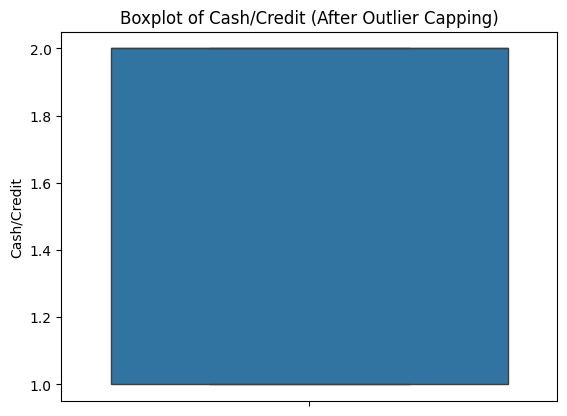

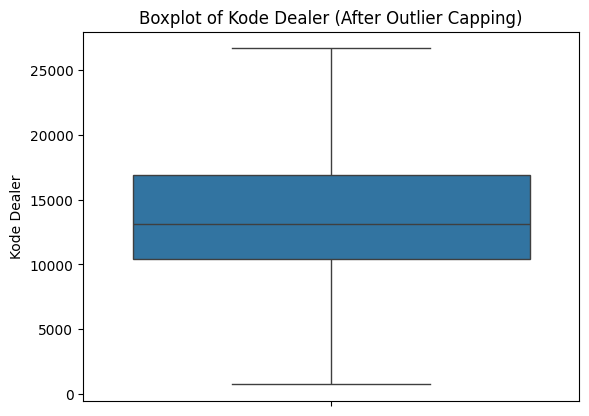

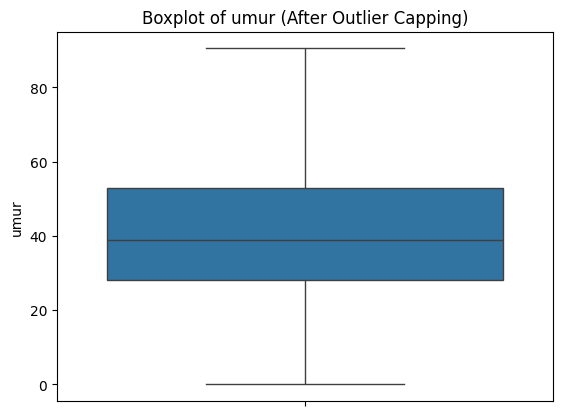

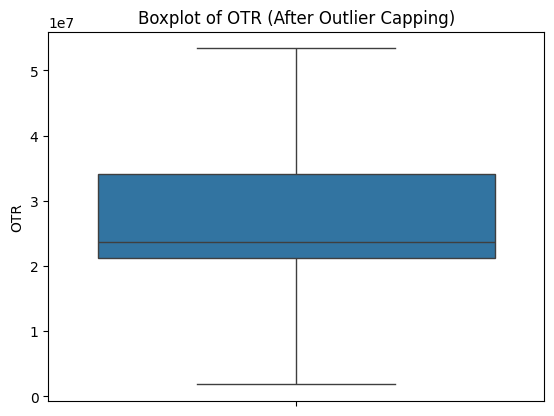

In [ ]:
for cols in num_cols:
  sns.boxplot(df_drop[cols])
  plt.title(f'Boxplot of {cols} (After Outlier Capping)')
  plt.show()

In [ ]:
df_drop=df_drop.drop(columns="Tgl Lahir")


In [ ]:
df_drop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317637 entries, 0 to 319977
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer ID         317636 non-null  object 
 1   Kelurahan           317634 non-null  object 
 2   Kecamatan           317635 non-null  object 
 3   Kode POS            317635 non-null  object 
 4   Cash/Credit         317635 non-null  float64
 5   Kode Dealer         317635 non-null  float64
 6   Finance Company     317562 non-null  object 
 7   Tenor               317614 non-null  object 
 8   Gender              317634 non-null  object 
 9   Agama               317635 non-null  object 
 10  Pekerjaan           317635 non-null  object 
 11  umur                317635 non-null  float64
 12  dp aktual           316937 non-null  object 
 13  cicilan             316979 non-null  object 
 14  warna               317635 non-null  object 
 15  dealer              317635 non-null  ob

In [ ]:
num_cols=df_drop.select_dtypes(include=np.number).columns
num_cols

Index(['Cash/Credit', 'Kode Dealer', 'umur', 'OTR'], dtype='object')

In [ ]:
cat_cols=df_drop.select_dtypes(exclude=np.number).columns
cat_cols

Index(['Customer ID', 'Kelurahan', 'Kecamatan', 'Kode POS', 'Finance Company',
       'Tenor', 'Gender', 'Agama', 'Pekerjaan', 'dp aktual', 'cicilan',
       'warna', 'dealer', 'type series', 'range dp', 'wilayah', '9 segment',
       'kode motor', 'tahun rakit', 'Kode Kota-Provinsi'],
      dtype='object')

In [ ]:
for cols in num_cols:
  df_drop[cols]=df_drop[cols].fillna(df_drop[cols].mean())
df_drop.isnull().sum()

,0
Customer ID,1
Kelurahan,3
Kecamatan,2
Kode POS,2
Cash/Credit,0
Kode Dealer,0
Finance Company,75
Tenor,23
Gender,3
Agama,2


In [ ]:
df_drop.head()

,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Agama,...,warna,dealer,type series,range dp,wilayah,9 segment,kode motor,OTR,tahun rakit,Kode Kota-Provinsi
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1,...,MC,Balikpapan,BREEZ SERIES,2 - 3 juta,6471,AT LOW,HN,18685000.0,NaN,6471-6400
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1,...,MC,Balikpapan,BREEZ SERIES,3 jt up,6471,AT LOW,HN,18685000.0,NaN,6471-6400
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1,...,MH,Balikpapan,SCOOTY SERIES,kurang 1 juta,6471,AT MID,HR,20775000.0,NaN,6471-6400
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1,...,MH,Balikpapan,SCOOTY SERIES,krg 1 jt,6471,AT MID,HR,20775000.0,NaN,6471-6400
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1,...,MH,Balikpapan,SCOOTY SERIES,2 - 3 jt,6471,AT MID,HR,20775000.0,NaN,6471-6400


In [ ]:
import pandas as pd
import re
import numpy as np

def clean_currency_column(col):
    """
    Bersihkan kolom finansial jadi float.

    Parameters:
        col : pd.Series
            Kolom bertipe object/string yang berisi nominal uang

    Returns:
        pd.Series float
    """
    def convert(x):
        if pd.isnull(x):
            return 0.0
        x = str(x).lower().replace('rp','').replace(' ','')
        # jika ada kata "juta", konversi ke angka
        if 'juta' in x:
            x = x.replace('juta','').replace(',', '.')
            try:
                return float(x) * 1_000_000
            except:
                return 0.0
        # ambil angka dan titik saja
        x = re.sub(r'[^0-9.]', '', x)
        if x == '':
            return 0.0
        try:
            return float(x)
        except:
            return 0.0

    return col.apply(convert)

In [ ]:
from pandas.core.arrays.floating import Float64Dtype
for col in ['dp aktual','cicilan']:
    df_drop[col] = clean_currency_column(df[col])

In [ ]:
df_drop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317637 entries, 0 to 319977
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer ID         317636 non-null  object 
 1   Kelurahan           317634 non-null  object 
 2   Kecamatan           317635 non-null  object 
 3   Kode POS            317635 non-null  object 
 4   Cash/Credit         317637 non-null  float64
 5   Kode Dealer         317637 non-null  float64
 6   Finance Company     317562 non-null  object 
 7   Tenor               317614 non-null  object 
 8   Gender              317634 non-null  object 
 9   Agama               317635 non-null  object 
 10  Pekerjaan           317635 non-null  object 
 11  umur                317637 non-null  float64
 12  dp aktual           317637 non-null  float64
 13  cicilan             317637 non-null  float64
 14  warna               317635 non-null  object 
 15  dealer              317635 non-null  ob

In [ ]:
df_drop.head()

,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Agama,...,warna,dealer,type series,range dp,wilayah,9 segment,kode motor,OTR,tahun rakit,Kode Kota-Provinsi
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1,...,MC,Balikpapan,BREEZ SERIES,2 - 3 juta,6471,AT LOW,HN,18685000.0,NaN,6471-6400
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1,...,MC,Balikpapan,BREEZ SERIES,3 jt up,6471,AT LOW,HN,18685000.0,NaN,6471-6400
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1,...,MH,Balikpapan,SCOOTY SERIES,kurang 1 juta,6471,AT MID,HR,20775000.0,NaN,6471-6400
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1,...,MH,Balikpapan,SCOOTY SERIES,krg 1 jt,6471,AT MID,HR,20775000.0,NaN,6471-6400
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1,...,MH,Balikpapan,SCOOTY SERIES,2 - 3 jt,6471,AT MID,HR,20775000.0,NaN,6471-6400


In [ ]:
def normalize_salary(x):
    if pd.isnull(x):
        return 'unknown'
    x = x.lower()
    if 'kurang' in x or 'krg' in x or '1 jt' in x and '-' not in x:
        return '<1 juta'
    elif '1 - 2' in x:
        return '1-2 juta'
    elif '2 - 3' in x:
        return '2-3 juta'
    elif '3' in x and 'up' in x:
        return '>3 juta'
    else:
        return 'other'

df_drop['range dp'] = df_drop['range dp'].apply(normalize_salary)

In [ ]:
df_drop=df_drop.drop(columns="tahun rakit")

In [ ]:
df_drop.head(10)

,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Agama,...,cicilan,warna,dealer,type series,range dp,wilayah,9 segment,kode motor,OTR,Kode Kota-Provinsi
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1,...,0.0,MC,Balikpapan,BREEZ SERIES,2-3 juta,6471,AT LOW,HN,18685000.0,6471-6400
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1,...,20600000.0,MC,Balikpapan,BREEZ SERIES,>3 juta,6471,AT LOW,HN,18685000.0,6471-6400
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1,...,0.0,MH,Balikpapan,SCOOTY SERIES,<1 juta,6471,AT MID,HR,20775000.0,6471-6400
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1,...,0.0,MH,Balikpapan,SCOOTY SERIES,<1 juta,6471,AT MID,HR,20775000.0,6471-6400
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1,...,12200000.0,MH,Balikpapan,SCOOTY SERIES,2-3 juta,6471,AT MID,HR,20775000.0,6471-6400
5,CUST-218443,Klandasan Ilir,Balikpapan Kota,76113,2.0,10411.0,1,2,2,1,...,13500000.0,MH,Balikpapan,SCOOTY SERIES,>3 juta,6471,AT MID,HR,20775000.0,6471-6400
6,CUST-199394,Klandasan Ilir,Balikpapan Kota,76113,1.0,12757.0,N,N,1,1,...,0.0,MH,Balikpapan,SCOOTY SERIES,<1 juta,6471,AT MID,HR,20775000.0,6471-6400
7,CUST-200209,KLANDASAN ULU,BALIKPAPAN KOTA,76112,1.0,733.0,N,N,1,1,...,0.0,BK,Balikpapan,BREEZ SERIES,<1 juta,6471,AT LOW,HO,17975000.0,6471-6400
8,CUST-09898,TELAGA SARI,BALIKPAPAN KOTA,45261,1.0,733.0,N,N,1,1,...,0.0,BK,Balikpapan,VAREX 125 SERIES,<1 juta,6471,AT MID,HB,22495000.0,6471-6400
9,CUST-194316,DAMAI BAHAGIA,BALIKPAPAN SELATAN,76114,1.0,733.0,N,N,2,1,...,0.0,BK,Balikpapan,RYVO SERIES,<1 juta,6471,CUB LOW,GF,17460000.0,6471-6400


In [ ]:
df_drop['range dp'].unique()

array(['2-3 juta', '>3 juta', '<1 juta', '1-2 juta', 'unknown'],
      dtype=object)

In [ ]:
for i in num_cols:
  df_drop[i]=df_drop[i].fillna(df_drop[i].mean())
df_drop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317637 entries, 0 to 319977
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer ID         317636 non-null  object 
 1   Kelurahan           317634 non-null  object 
 2   Kecamatan           317635 non-null  object 
 3   Kode POS            317635 non-null  object 
 4   Cash/Credit         317637 non-null  float64
 5   Kode Dealer         317637 non-null  float64
 6   Finance Company     317562 non-null  object 
 7   Tenor               317614 non-null  object 
 8   Gender              317634 non-null  object 
 9   Agama               317635 non-null  object 
 10  Pekerjaan           317635 non-null  object 
 11  umur                317637 non-null  float64
 12  dp aktual           317637 non-null  float64
 13  cicilan             317637 non-null  float64
 14  warna               317635 non-null  object 
 15  dealer              317635 non-null  ob

In [ ]:
df_drop.isnull().sum()

,0
Customer ID,1
Kelurahan,3
Kecamatan,2
Kode POS,2
Cash/Credit,0
Kode Dealer,0
Finance Company,75
Tenor,23
Gender,3
Agama,2


In [ ]:
num_cols=df_drop.select_dtypes(include=np.number).columns
num_cols

Index(['Cash/Credit', 'Kode Dealer', 'umur', 'dp aktual', 'cicilan', 'OTR'], dtype='object')

In [ ]:
cat_cols=df_drop.select_dtypes(exclude=np.number).columns
cat_cols

Index(['Customer ID', 'Kelurahan', 'Kecamatan', 'Kode POS', 'Finance Company',
       'Tenor', 'Gender', 'Agama', 'Pekerjaan', 'warna', 'dealer',
       'type series', 'range dp', 'wilayah', '9 segment', 'kode motor',
       'Kode Kota-Provinsi'],
      dtype='object')

In [ ]:
for cols in cat_cols:
  df_drop[cols]=df_drop[cols].fillna(df_drop[cols].mode()[0])
df_drop.isnull().sum()

,0
Customer ID,0
Kelurahan,0
Kecamatan,0
Kode POS,0
Cash/Credit,0
Kode Dealer,0
Finance Company,0
Tenor,0
Gender,0
Agama,0


In [ ]:
df_drop.columns

Index(['Customer ID', 'Kelurahan', 'Kecamatan', 'Kode POS', 'Cash/Credit',
       'Kode Dealer', 'Finance Company', 'Tenor', 'Gender', 'Agama',
       'Pekerjaan', 'umur', 'dp aktual', 'cicilan', 'warna', 'dealer',
       'type series', 'range dp', 'wilayah', '9 segment', 'kode motor', 'OTR',
       'Kode Kota-Provinsi'],
      dtype='object')

In [ ]:
# hitung jumlah transaksi per customer
df_drop['repeat_flag'] = df_drop.groupby('Customer ID')['Customer ID'].transform('count').gt(1).astype(int)

In [ ]:
df_drop.head()

,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Agama,...,warna,dealer,type series,range dp,wilayah,9 segment,kode motor,OTR,Kode Kota-Provinsi,repeat_flag
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1,...,MC,Balikpapan,BREEZ SERIES,2-3 juta,6471,AT LOW,HN,18685000.0,6471-6400,0
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1,...,MC,Balikpapan,BREEZ SERIES,>3 juta,6471,AT LOW,HN,18685000.0,6471-6400,0
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1,...,MH,Balikpapan,SCOOTY SERIES,<1 juta,6471,AT MID,HR,20775000.0,6471-6400,1
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1,...,MH,Balikpapan,SCOOTY SERIES,<1 juta,6471,AT MID,HR,20775000.0,6471-6400,1
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1,...,MH,Balikpapan,SCOOTY SERIES,2-3 juta,6471,AT MID,HR,20775000.0,6471-6400,0


In [ ]:
cat_cols

Index(['Customer ID', 'Kelurahan', 'Kecamatan', 'Kode POS', 'Finance Company',
       'Tenor', 'Gender', 'Agama', 'Pekerjaan', 'warna', 'dealer',
       'type series', 'range dp', 'wilayah', '9 segment', 'kode motor',
       'Kode Kota-Provinsi'],
      dtype='object')

In [ ]:
df_drop.value_counts('Finance Company')

,count
Finance Company,
N,137181
1,134645
2,13823
4,9706
11,7109
5,6379
3,3318
9,2052
13,1629


In [ ]:
df_drop['Tenor'] = df_drop['Tenor'].replace('N',0)
df_drop['Finance Company'] = df_drop['Finance Company'].replace('N','unknown')

In [ ]:
df_drop.head()

,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Agama,...,warna,dealer,type series,range dp,wilayah,9 segment,kode motor,OTR,Kode Kota-Provinsi,repeat_flag
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1,...,MC,Balikpapan,BREEZ SERIES,2-3 juta,6471,AT LOW,HN,18685000.0,6471-6400,0
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1,...,MC,Balikpapan,BREEZ SERIES,>3 juta,6471,AT LOW,HN,18685000.0,6471-6400,0
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,unknown,0,2,1,...,MH,Balikpapan,SCOOTY SERIES,<1 juta,6471,AT MID,HR,20775000.0,6471-6400,1
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,unknown,0,2,1,...,MH,Balikpapan,SCOOTY SERIES,<1 juta,6471,AT MID,HR,20775000.0,6471-6400,1
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1,...,MH,Balikpapan,SCOOTY SERIES,2-3 juta,6471,AT MID,HR,20775000.0,6471-6400,0


In [ ]:
for col in ['Kelurahan','Kecamatan','Kode POS','type series','dealer','wilayah']:
  freq = df_drop[col].value_counts()
  df_drop[col] = df_drop[col].map(freq)

In [ ]:
# jumlah transaksi
df_drop['total_transaksi'] = df_drop.groupby('Customer ID')['Customer ID'].transform('count')

# total pembelian
df_drop['total_otr'] = df_drop.groupby('Customer ID')['OTR'].transform('sum')

# rata-rata DP
df_drop['avg_dp'] = df_drop.groupby('Customer ID')['dp aktual'].transform('mean')
df_drop['dp_ratio'] = df_drop['dp aktual'] / df_drop['OTR']
df_drop['cicilan_ratio'] = df_drop['cicilan'] / df_drop['OTR']
# jumlah dealer unik
df_drop['unique_dealer'] = df_drop.groupby('Customer ID')['Kode Dealer'].transform('nunique')

# jumlah finance unik
df_drop['unique_finance'] = df_drop.groupby('Finance Company')['Finance Company'].transform('nunique')

In [ ]:
df_drop=df_drop.drop(columns=['Agama','Kode Kota-Provinsi'])

In [ ]:
df_drop['Tenor']=df_drop['Tenor'].astype(int)

In [ ]:
df_drop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317637 entries, 0 to 319977
Data columns (total 29 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Customer ID      317637 non-null  object 
 1   Kelurahan        317637 non-null  int64  
 2   Kecamatan        317637 non-null  int64  
 3   Kode POS         317637 non-null  int64  
 4   Cash/Credit      317637 non-null  float64
 5   Kode Dealer      317637 non-null  float64
 6   Finance Company  317637 non-null  object 
 7   Tenor            317637 non-null  int64  
 8   Gender           317637 non-null  object 
 9   Pekerjaan        317637 non-null  object 
 10  umur             317637 non-null  float64
 11  dp aktual        317637 non-null  float64
 12  cicilan          317637 non-null  float64
 13  warna            317637 non-null  object 
 14  dealer           317637 non-null  int64  
 15  type series      317637 non-null  int64  
 16  range dp         317637 non-null  object 
 

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['warna','range dp','Finance Company']:
    df_drop[col] = le.fit_transform(df_drop[col])

In [ ]:
df_drop=df_drop.drop(columns="Customer ID")

In [ ]:
cat_cols=df_drop.select_dtypes(exclude=np.number).columns
cat_cols

Index(['Gender', 'Pekerjaan', '9 segment', 'kode motor'], dtype='object')

In [ ]:
df_drop['Gender']=df_drop['Gender'].replace('N',df_drop['Gender'].mode()[0])

In [ ]:
df_drop = pd.get_dummies(df_drop, columns=cat_cols, drop_first=False)

In [ ]:
df_drop.head()

,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,umur,dp aktual,cicilan,...,kode motor_MU,kode motor_MV,kode motor_MX,kode motor_MY,kode motor_MZ,kode motor_ND,kode motor_NE,kode motor_NF,kode motor_NG,kode motor_NH
0,234,1118,2782,2.0,12756.0,11,3,27.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,3147,14141,1363,2.0,733.0,0,1,28.0,87800000.0,20600000.0,...,False,False,False,False,False,False,False,False,False,False
2,3147,14141,1363,1.0,733.0,15,0,37.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,3147,14141,1363,1.0,733.0,15,0,22.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,247,1118,1370,2.0,11160.0,0,2,23.0,21000000.0,12200000.0,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
X=df_drop.drop(columns=["repeat_flag","total_transaksi"])
y=df_drop["repeat_flag"]

In [ ]:
y.value_counts()

,count
repeat_flag,
0,231654
1,85983


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
y_train_res.value_counts()

,count
repeat_flag,
1,185323
0,185323


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42,max_depth=2)

rf.fit(X_train_res, y_train_res)

RandomForestClassifier(max_depth=2, n_estimators=200, random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[43311  3020]
 [ 2445 14752]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94     46331
           1       0.83      0.86      0.84     17197

    accuracy                           0.91     63528
   macro avg       0.89      0.90      0.89     63528
weighted avg       0.92      0.91      0.91     63528



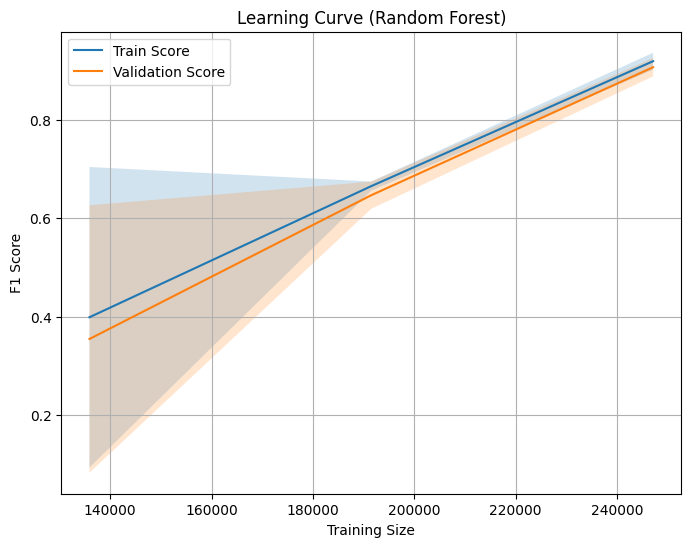

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    rf,
    X_train_res,
    y_train_res,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)
plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label='Train Score')
plt.plot(train_sizes, val_mean, label='Validation Score')

# optional: shading
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.2)

plt.xlabel('Training Size')
plt.ylabel('F1 Score')
plt.title('Learning Curve (Random Forest)')
plt.legend()
plt.grid()
plt.show()

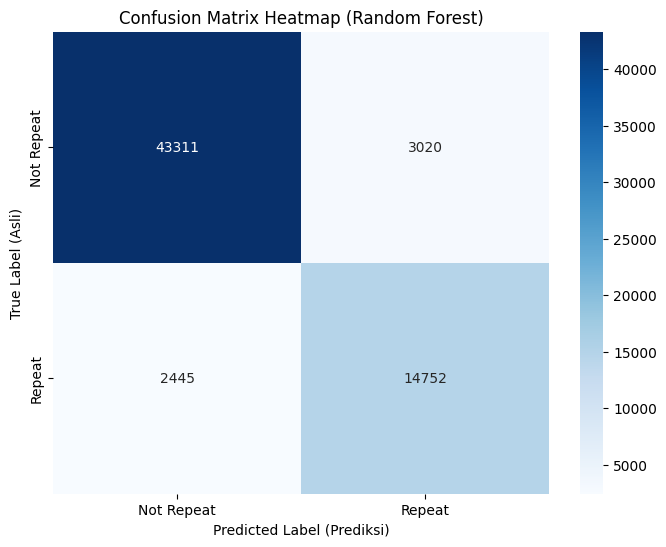

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Lakukan prediksi pada data test
y_pred = rf.predict(X_test)

# 2. Buat matriks kebingungan (confusion matrix)
cm = confusion_matrix(y_test, y_pred)

# 3. Visualisasikan dengan Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Repeat', 'Repeat'],
            yticklabels=['Not Repeat', 'Repeat'])

plt.title('Confusion Matrix Heatmap (Random Forest)')
plt.xlabel('Predicted Label (Prediksi)')
plt.ylabel('True Label (Asli)')
plt.show()

###MODEL COCOK DAN MENDAPATKAN LEARNING RATE CURVE YANG IDEAL

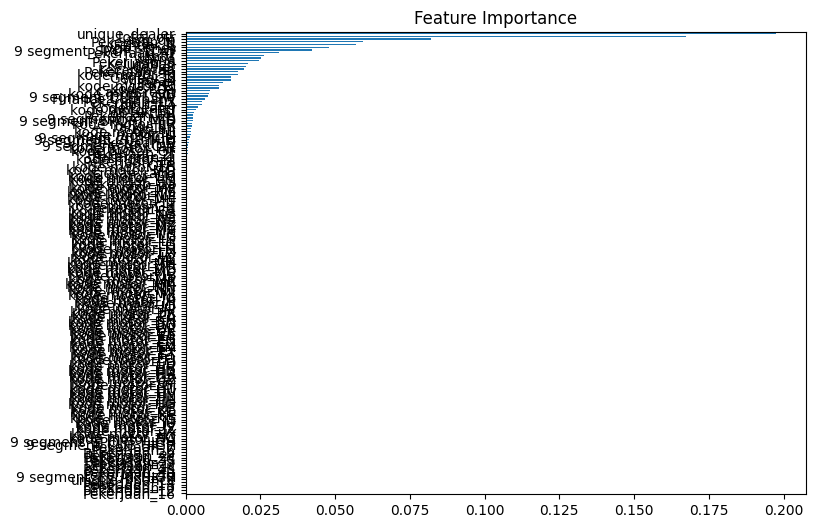

In [ ]:
import matplotlib.pyplot as plt

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

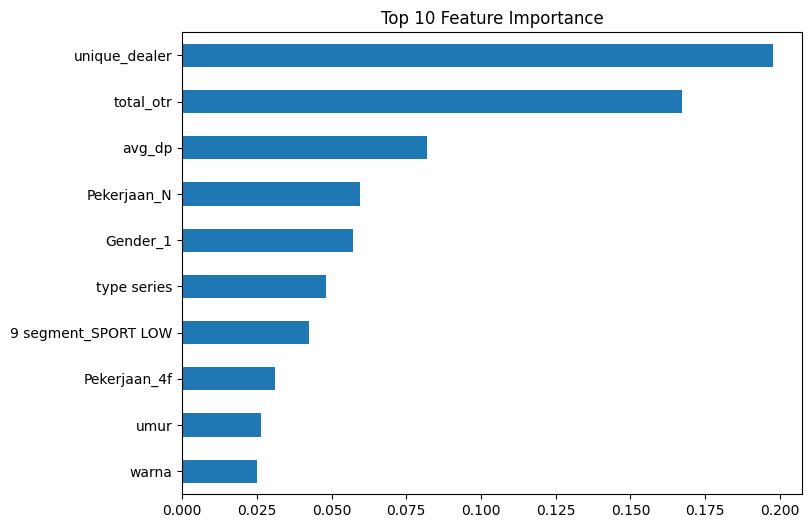

In [ ]:
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = feat_importances.sort_values(ascending=False).head(10)
import matplotlib.pyplot as plt

top10.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Top 10 Feature Importance")
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5)

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')

print("F1 per fold:", scores)
print("Mean F1:", scores.mean())

F1 per fold: [0.99947638 0.99968589 0.99937157]
Mean F1: 0.999511281656809


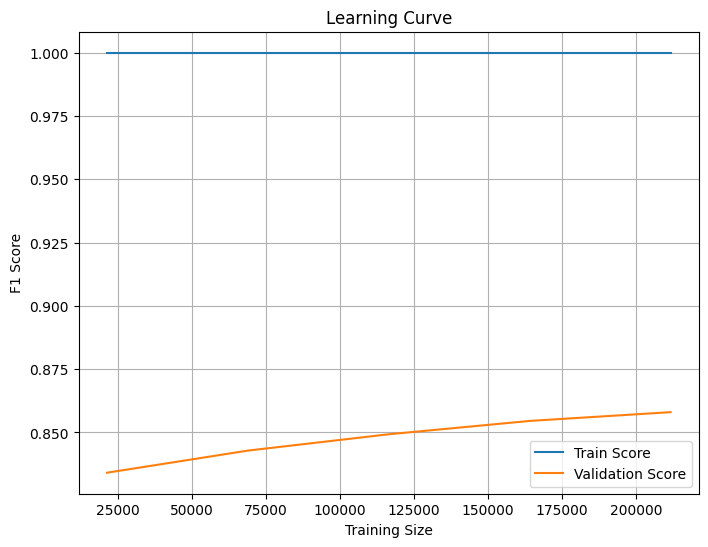

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    pipeline, X, y,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label='Train Score')
plt.plot(train_sizes, val_mean, label='Validation Score')

plt.xlabel('Training Size')
plt.ylabel('F1 Score')
plt.title('Learning Curve')
plt.legend()
plt.grid()
plt.show()

##MODEL OVERFIT KARENA DATA SEDERHANA DAN MODEL TERLALU KOMPLEKS UNTUK DATA

Confusion Matrix:
[[231653      1]
 [    83  85900]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    231654
           1       1.00      1.00      1.00     85983

    accuracy                           1.00    317637
   macro avg       1.00      1.00      1.00    317637
weighted avg       1.00      1.00      1.00    317637



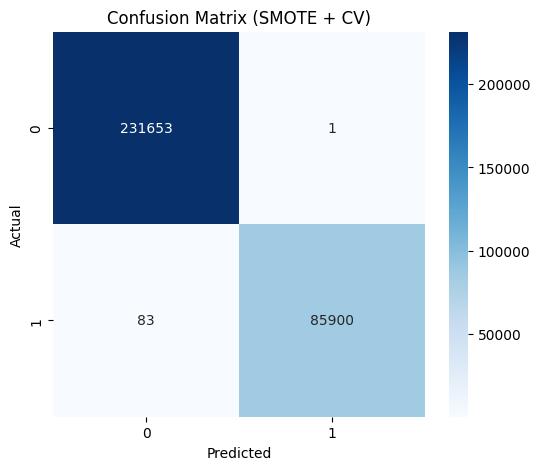

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Generate prediction dari CV
y_pred = cross_val_predict(pipeline, X, y, cv=cv)

# 🔹 Confusion Matrix
cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)

# 🔹 Classification Report
print("\nClassification Report:")
print(classification_report(y, y_pred))

# 🔹 Visualisasi
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (SMOTE + CV)')
plt.show()